In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(
    "series temporales.xlsx",
    sheet_name="CONSUMO",
    parse_dates=["Fecha"]          # <- convierte 'Fecha' a datetime desde el inicio
)
df

,Fecha,Aceites lubricantes,Asfalto,Bunker,Ceras,Combustible turbo jet,Diesel bajo azufre,Diesel ultra bajo azufre,Gas licuado de petróleo,Gas natural,...,Kerosina,Mezclas\noleosas,Naftas,PetCoke,Petróleo crudo,Solventes,Butano,Diesel alto azufre,Orimulsión,Total
0,2000-01-01,0.00,48446.00,296766.99,0.00,0.00,0.00,0.00,194410.476190,NaN,...,64026.09,0.00,0.00,0.00,0.00,0.00,0.0,634667.06,0,1.750545e+06
1,2000-02-01,0.00,50597.00,328116.44,0.00,0.00,0.00,0.00,174710.552381,NaN,...,62660.30,0.00,0.00,0.00,0.00,0.00,0.0,642380.66,0,1.773220e+06
2,2000-03-01,0.00,27593.00,368589.63,0.00,0.00,0.00,0.00,189234.066667,NaN,...,61361.99,0.00,0.00,0.00,0.00,0.00,0.0,699807.25,0,1.909499e+06
3,2000-04-01,0.00,53794.00,396300.47,0.00,0.00,0.00,0.00,174330.607143,NaN,...,61814.32,0.00,0.00,0.00,0.00,0.00,0.0,586803.98,0,1.800933e+06
4,2000-05-01,0.00,60137.00,449368.92,0.00,0.00,0.00,0.00,191745.147619,NaN,...,54098.32,0.00,0.00,0.00,0.00,0.00,0.0,656948.20,0,1.941772e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2024-08-01,32669.87,16086.77,155156.95,-129.83,88992.17,1220254.20,13769.72,551959.940000,-5125.38,...,145.23,1757.07,547.58,865931.91,84348.69,11037.39,0.0,0.00,0,4.617048e+06
296,2024-09-01,17724.39,14404.37,129059.65,-682.98,78639.27,1161480.31,14234.41,555676.210000,-3617.05,...,50.76,1442.97,92.59,491181.54,78185.20,16852.16,0.0,0.00,0,4.068636e+06
297,2024-10-01,2900.53,14718.66,168233.85,18.55,77767.06,1399433.57,15236.22,600476.170000,0.00,...,129.48,1816.42,301.66,487452.36,88885.31,15873.86,0.0,0.00,0,4.599042e+06
298,2024-11-01,26601.36,40510.01,126219.84,42.69,82355.21,1307939.01,24281.06,597059.900000,0.00,...,-405.57,3646.69,213.66,458139.11,77270.48,12489.70,0.0,0.00,0,4.281218e+06


In [2]:
gas_regular = df[["Fecha", "Gasolina regular"]].copy()
gas_regular = gas_regular.sort_values("Fecha")
gas_regular.set_index("Fecha", inplace=True)

# Serie 1D (evita problemas con funciones que exigen Series)
gas_regular_series = gas_regular["Gasolina regular"].astype(float)

In [3]:
gas_regular_series = gas_regular_series.asfreq('MS')

# Análisis Exploratorio

Dado que en el primer laboratorio se trabajó con varios conjuntos de datos, en esta ocasión simplificaremos el análisis tomando únicamente uno de ellos. En lugar de considerar las importaciones y el consumo de gasolina regular, superior y diésel de alto azufre, este laboratorio se enfocará exclusivamente en el consumo de gasolina regular.


Esta decisión se toma con el propósito de facilitar el desarrollo del laboratorio, manteniendo el cumplimiento de los requisitos establecidos en la guía, pero evitando que el trabajo se vuelva innecesariamente extenso o tedioso.


Cabe destacar que los procedimientos y análisis que se realicen con este conjunto de datos (la serie temporal de consumo de gasolina regular) son completamente aplicables a los demás conjuntos de datos, por lo que el enfoque elegido responde únicamente a razones de practicidad y claridad en el desarrollo de este ejercicio.

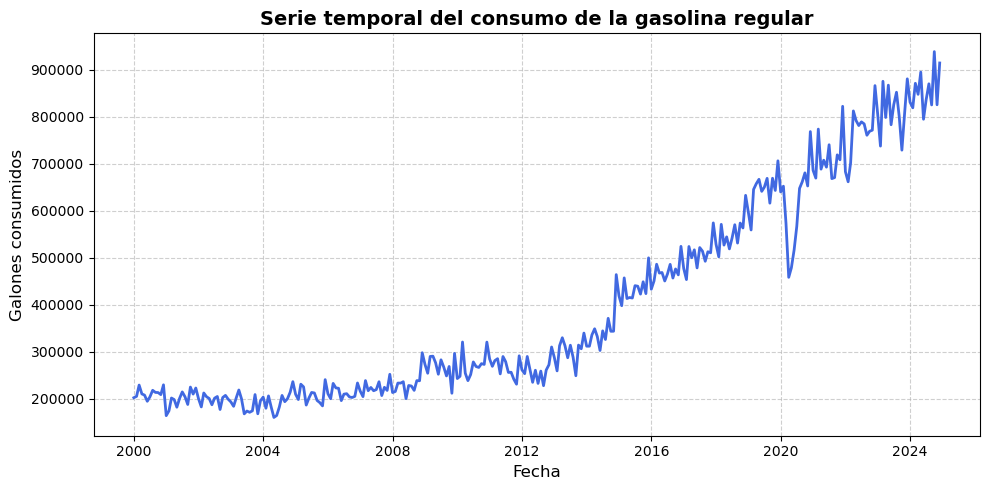

In [4]:
plt.figure(figsize=(10, 5)) 
plt.plot(gas_regular_series, color='royalblue', linewidth=2)

# Títulos y etiquetas
plt.title('Serie temporal del consumo de la gasolina regular', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Galones consumidos', fontsize=12)

# Cuadrícula y estilo
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

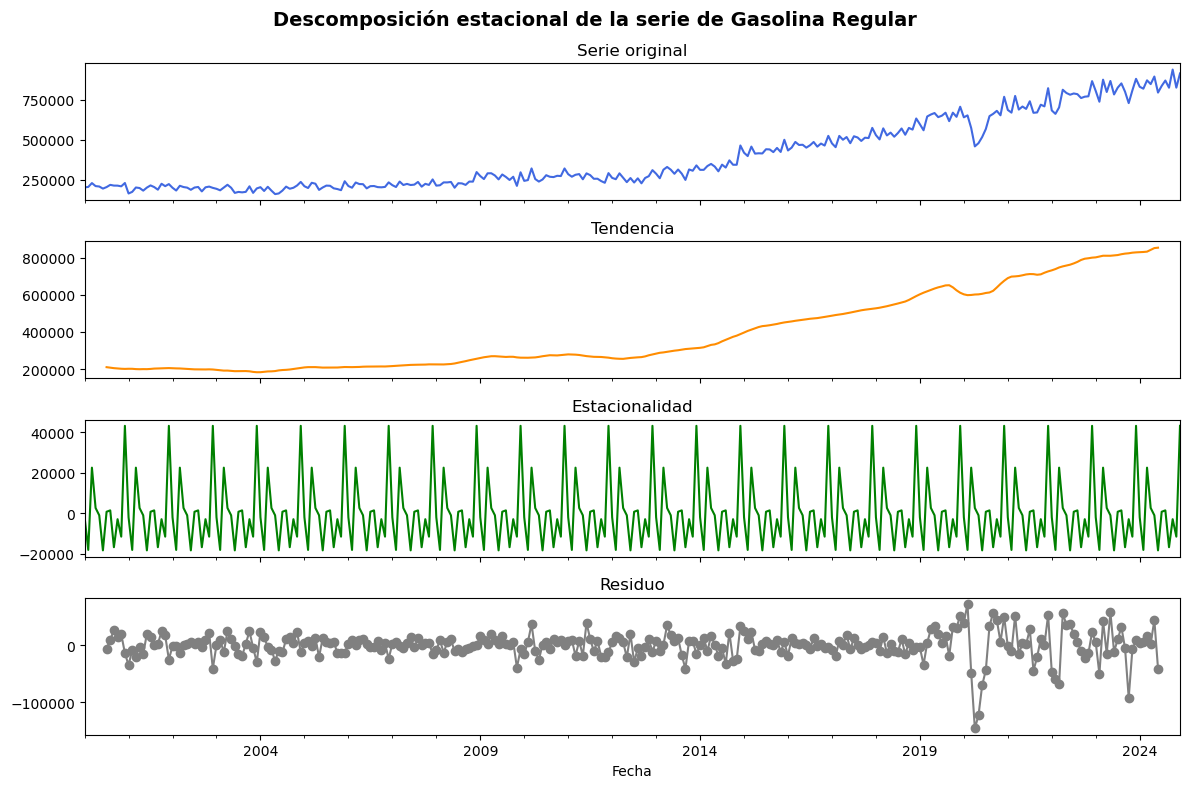

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Descomposición
result = seasonal_decompose(gas_regular_series, model='additive', period=12)

# Crear figura y ejes
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# Graficar cada componente
result.observed.plot(ax=axes[0], color='royalblue', linewidth=1.5, title='Serie original')
result.trend.plot(ax=axes[1], color='darkorange', linewidth=1.5, title='Tendencia')
result.seasonal.plot(ax=axes[2], color='green', linewidth=1.5, title='Estacionalidad')
result.resid.plot(ax=axes[3], color='gray', linewidth=1.5, title='Residuo',marker="o")

# Ajustes generales
fig.suptitle('Descomposición estacional de la serie de Gasolina Regular', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

De la descomposicion espectral, se puede percibir que la serie temporal no es estacionaria, pero para estár más seguros y no dependa solamente del criterio del analista pasemos a ver esto en una prueba de hipótesis. Entonces considerando un nivel de confianza del 95% y $h_0 = $ La serie tiene una raíz unitaria (no estacionaria) y $h_1 = $ La serie no tiene raices unitarias. Se realiza la pruebda de Dickey-Fuller aumentada. 

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(gas_regular_series.dropna())  # asegúrate de no tener NaNs
print("p-value:", result[1])

p-value: 0.9990426899915509


Como el valor-p no es menor que 0.05, no hay evidencia suficiente para rechazar la hipótesis nula, por lo que la serie tiene raices unitarias (no es estacionaria)

# Transformaciones hacia la estacionariedad

Debido a la tendencia se aplicara una transformacion logarítmica así como una diferenciación simple. Por otra parte, debido a la estacionalidad que se puede observar de 12 meses, se aplicará tambien una diferenciación estacional de 12. Luego se comprobará si la serie resultante es estacionaria para proceder a las funciones de autocorrelacion y autocorrelación parcial. 

In [7]:
import numpy as np

log_series = np.log(gas_regular_series).dropna()
diff_simple = log_series.diff().dropna()
gas_regular_stationary = diff_simple.diff(12).dropna()

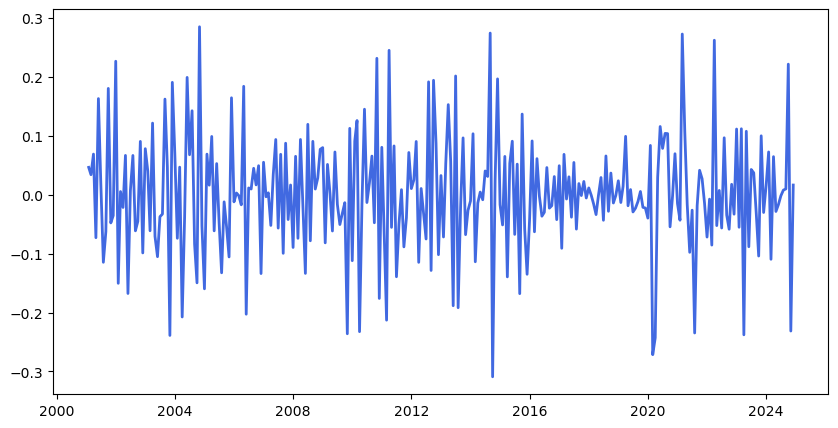

In [8]:
plt.figure(figsize=(10, 5)) 
plt.plot(gas_regular_stationary, color='royalblue', linewidth=2)
plt.show()

In [9]:
result_stationary = adfuller(gas_regular_stationary.dropna())
print("p-value:", result_stationary[1])

p-value: 1.3779600355472719e-12


Al hacer nuevamente la prueba de hipótesis para la serie transformada obtenemos un valor-p $\leq 0.05$ por lo que hay evidencia suficiente para rechazar la hipótesis nula, por lo que la serie no tiene raíces unitarias o bien, la serie es estacionaria. Ya con la serie estacionaria pasemos a la visualizacion de la función de autocorrelación y autocorrelación parcial

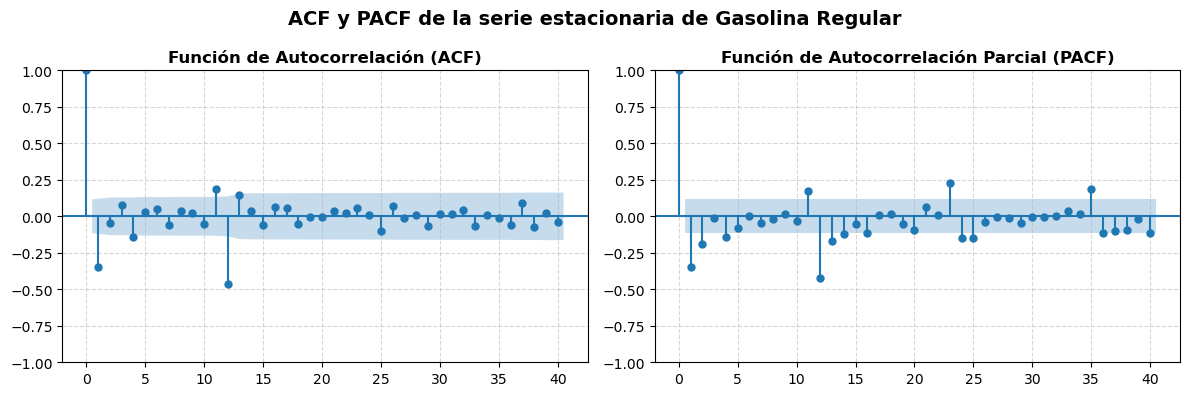

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Crear las dos gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Función de autocorrelación (ACF)
plot_acf(gas_regular_stationary, ax=axes[0], lags=40, alpha=0.05)
axes[0].set_title('Función de Autocorrelación (ACF)', fontsize=12, fontweight='bold')

# Función de autocorrelación parcial (PACF)
plot_pacf(gas_regular_stationary, ax=axes[1], lags=40, alpha=0.05, method='ywm')
axes[1].set_title('Función de Autocorrelación Parcial (PACF)', fontsize=12, fontweight='bold')

# Ajustes generales
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('ACF y PACF de la serie estacionaria de Gasolina Regular', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

| Símbolo | Significado                           | Qué hace                                                                    | Cómo se identifica                             |
| ------- | ------------------------------------- | --------------------------------------------------------------------------- | ---------------------------------------------- |
| **p**   | orden autorregresivo (AR)             | cuántos retardos pasados afectan el valor actual                            | PACF                                           |
| **d**   | orden de diferenciación no estacional | elimina tendencia                                                           | ya lo aplicaste al hacer estacionaria la serie |
| **q**   | orden de media móvil (MA)             | cuántos errores pasados influyen en el valor actual                         | ACF                                            |
| **P**   | orden autorregresivo estacional       | retardo estacional (por ejemplo, un año atrás si s=12)                      | PACF (picos en múltiplos de s)                 |
| **D**   | diferenciación estacional             | elimina patrones repetitivos                                                | ya la aplicaste si hiciste `.diff(12)`         |
| **Q**   | orden de media móvil estacional       | errores pasados en la componente estacional                                 | ACF (picos en múltiplos de s)                  |
| **s**   | periodo estacional                    | número de observaciones por ciclo (12 si es mensual, 7 si es semanal, etc.) | según tus datos                                |


In [11]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelos_candidatos = [
    ( (0,1,0), (0,1,0,12) ), # SARIMA(0,1,0)(0,1,0)12
    ( (1,1,0), (0,1,0,12) ), # SARIMA(1,1,0)(0,1,0)12
    ( (0,1,1), (0,1,0,12) ), # SARIMA(0,1,1)(0,1,0)12
    ( (1,1,1), (0,1,0,12) ), # SARIMA(1,1,1)(0,1,0)12
    ( (0,1,0), (1,1,0,12) ), # SARIMA(0,1,0)(1,1,0)12
    ( (0,1,0), (0,1,1,12) ), # SARIMA(0,1,0)(0,1,1)12
    ( (1,1,0), (1,1,0,12) ), # SARIMA(1,1,0)(1,1,0)12
    ( (0,1,1), (0,1,1,12) ), # SARIMA(0,1,1)(0,1,1)12
]

resultados_modelos = {}

# Bucle para estimar y comparar cada modelo
for orden_no_estacional, orden_estacional in modelos_candidatos:
    try:
        # Crear y ajustar el modelo SARIMAX usando 'gas_regular_series'
        modelo = SARIMAX(gas_regular_series,
                         order=orden_no_estacional,
                         seasonal_order=orden_estacional,
                         enforce_stationarity=False,
                         enforce_invertibility=False)
        
        resultado = modelo.fit(disp=False)
        
        # Almacenar el AIC y BIC en el diccionario
        nombre_modelo = f"SARIMA{orden_no_estacional}{orden_estacional}"
        resultados_modelos[nombre_modelo] = {
            'AIC': resultado.aic,
            'BIC': resultado.bic
        }
        
        print(f"Modelo {nombre_modelo} ajustado. AIC: {resultado.aic}, BIC: {resultado.bic}")
        
    except Exception as e:
        print(f"No se pudo ajustar el modelo SARIMA{orden_no_estacional}{orden_estacional}. Error: {e}")

resultados_modelos = pd.DataFrame(resultados_modelos)
resultados_modelos = resultados_modelos.transpose()
resultados_modelos

Modelo SARIMA(0, 1, 0)(0, 1, 0, 12) ajustado. AIC: 6901.568223598507, BIC: 6905.2242154093265
Modelo SARIMA(1, 1, 0)(0, 1, 0, 12) ajustado. AIC: 6866.757189067278, BIC: 6874.069172688918
Modelo SARIMA(0, 1, 1)(0, 1, 0, 12) ajustado. AIC: 6839.950168283295, BIC: 6847.255146643833
Modelo SARIMA(1, 1, 1)(0, 1, 0, 12) ajustado. AIC: 6839.381001463623, BIC: 6850.338469004429
Modelo SARIMA(0, 1, 0)(1, 1, 0, 12) ajustado. AIC: 6555.473071760323, BIC: 6562.706613955656
Modelo SARIMA(0, 1, 0)(0, 1, 1, 12) ajustado. AIC: 6486.004485900484, BIC: 6493.23074211326
Modelo SARIMA(1, 1, 0)(1, 1, 0, 12) ajustado. AIC: 6517.191436182061, BIC: 6528.030820501225
Modelo SARIMA(0, 1, 1)(0, 1, 1, 12) ajustado. AIC: 6448.966375994001, BIC: 6459.794791379556


,AIC,BIC
"SARIMA(0, 1, 0)(0, 1, 0, 12)",6901.568224,6905.224215
"SARIMA(1, 1, 0)(0, 1, 0, 12)",6866.757189,6874.069173
"SARIMA(0, 1, 1)(0, 1, 0, 12)",6839.950168,6847.255147
"SARIMA(1, 1, 1)(0, 1, 0, 12)",6839.381001,6850.338469
"SARIMA(0, 1, 0)(1, 1, 0, 12)",6555.473072,6562.706614
"SARIMA(0, 1, 0)(0, 1, 1, 12)",6486.004486,6493.230742
"SARIMA(1, 1, 0)(1, 1, 0, 12)",6517.191436,6528.030821
"SARIMA(0, 1, 1)(0, 1, 1, 12)",6448.966376,6459.794791


In [12]:
min(resultados_modelos["AIC"])

6448.966375994001

De la generacion de los modelos y la comparacion de AIC podemos ver que el mejor modelo hasta ahora es el SARIMA(0,1,1)(0,1,1,12). Vamos a predecir con este modelo y luego vamos a comparar con los datos reales. 

# Predicciones Modelo SARIMA(0,1,1)(0,1,1,12)

In [13]:
modelo = SARIMAX(
    gas_regular_series,
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado = modelo.fit(disp=False)

print(resultado.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   Gasolina regular   No. Observations:                  300
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -3221.483
Date:                            Wed, 29 Oct 2025   AIC                           6448.966
Time:                                    22:19:33   BIC                           6459.795
Sample:                                01-01-2000   HQIC                          6453.313
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4030      0.053     -7.585      0.000      -0.507      -0.299
ma.S.L12      -0.7385      0.042   

In [14]:
pasos = 12
fc = resultado.get_forecast(steps=pasos)
fc_df = fc.summary_frame()
fc_df = fc_df.rename(columns={
    'mean': 'pronostico',
    'mean_ci_lower': 'IC_inferior',
    'mean_ci_upper': 'IC_superior'
})[['pronostico','IC_inferior','IC_superior']]
fc_df

Gasolina regular,pronostico,IC_inferior,IC_superior
2025-01-01,858312.031689,781139.537033,9.354845e+05
2025-02-01,833859.628285,743979.713265,9.237395e+05
2025-03-01,898244.981381,797243.969927,9.992460e+05
2025-04-01,871839.657926,760826.102423,9.828532e+05
2025-05-01,899132.671193,778937.768239,1.019328e+06
2025-06-01,852009.742092,723286.706520,9.807328e+05
2025-07-01,885566.858699,748846.614851,1.022287e+06
2025-08-01,899592.474196,755317.631384,1.043867e+06
2025-09-01,869263.805172,717810.725112,1.020717e+06
2025-10-01,899854.193452,741548.032326,1.058160e+06


In [15]:
fc_df_series = fc_df.copy()
fc_df_series = fc_df_series.drop(["IC_inferior","IC_superior"],axis = 1)
fc_df_series

Gasolina regular,pronostico
2025-01-01,858312.031689
2025-02-01,833859.628285
2025-03-01,898244.981381
2025-04-01,871839.657926
2025-05-01,899132.671193
2025-06-01,852009.742092
2025-07-01,885566.858699
2025-08-01,899592.474196
2025-09-01,869263.805172
2025-10-01,899854.193452


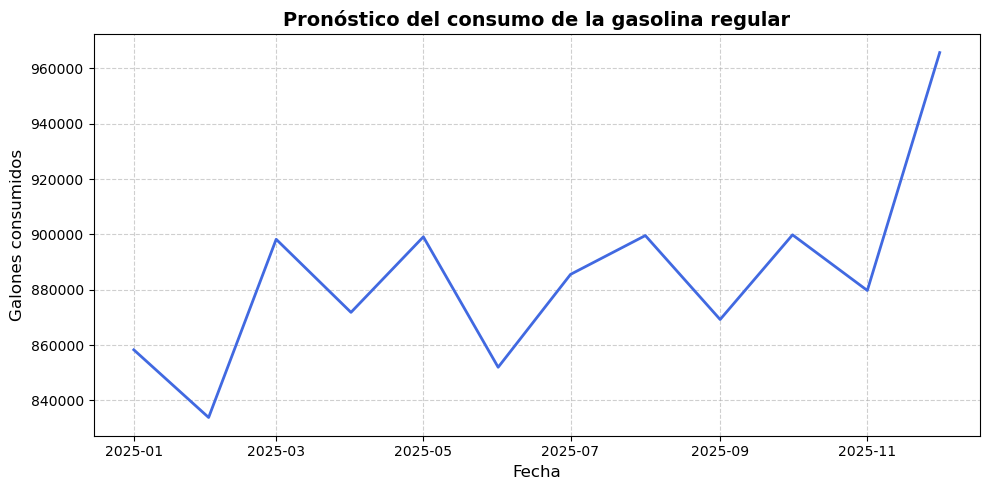

In [16]:
plt.figure(figsize=(10, 5)) 
plt.plot(fc_df_series, color='royalblue', linewidth=2)

# Títulos y etiquetas
plt.title('Pronóstico del consumo de la gasolina regular', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Galones consumidos', fontsize=12)

# Cuadrícula y estilo
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Dashboard

In [18]:
# ==========================================
# DASHBOARD – Pestaña 1 (Visualización) + Pestaña 2 (Modelado: AIC/BIC + Pronóstico)
# ==========================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from dash import Dash, html, dcc, Input, Output, dash_table

# ------------------------------
# PALETA
# ------------------------------
PALETTE = {
    "Pakistan_Green": "#134611",
    "India_Green":    "#3E8914",
    "Pigment_Green":  "#3DA35D",
    "Light_Green":    "#96E072",
    "Snow":           "#FFFAFB"
}

# ------------------------------
# TRANSFORMACIONES (pestaña 1)
# ------------------------------
result = seasonal_decompose(gas_regular_series, model='additive', period=12)
log_series = np.log(gas_regular_series).dropna()
diff_simple = log_series.diff().dropna()
gas_regular_stationary = diff_simple.diff(12).dropna()

# ---------- Utilidad: bloque de nota con estilo
def note_block(text):
    return html.Div(
        style={
            'backgroundColor': '#FFFFFF',
            'border': f'1px dashed {PALETTE["Pigment_Green"]}',
            'color': PALETTE['Pakistan_Green'],
            'padding': '10px',
            'marginTop': '8px',
            'borderRadius': '8px',
            'fontFamily': 'sans-serif',
            'fontSize': '14px',
            'lineHeight': '1.45'
        },
        children=html.P(text, style={'margin': 0})
    )

# ---------- Figuras (pestaña 1)
def fig_timeseries():
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=gas_regular_series.index, y=gas_regular_series.values,
        mode="lines", line=dict(color=PALETTE["India_Green"], width=2)
    ))
    fig.update_layout(title="Serie temporal del consumo de gasolina regular",
                      xaxis_title="Fecha", yaxis_title="Galones consumidos",
                      plot_bgcolor=PALETTE["Snow"], paper_bgcolor=PALETTE["Snow"],
                      font=dict(color=PALETTE["Pakistan_Green"]))
    return fig

def fig_decomposition():
    fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
                        subplot_titles=("Serie original","Tendencia","Estacionalidad","Residuo"))
    comps = [(result.observed,PALETTE['India_Green']),
             (result.trend,PALETTE['Pakistan_Green']),
             (result.seasonal,PALETTE['Pigment_Green']),
             (result.resid,PALETTE['Light_Green'])]
    for i,(serie,color) in enumerate(comps,1):
        fig.add_trace(go.Scatter(x=serie.index,y=serie.values,
                                 mode="lines" if i != 4 else "lines",
                                 line=dict(color=color,width=2)), row=i, col=1)
    fig.update_layout(height=900, title="Descomposición estacional de la serie de Gasolina Regular",
                      plot_bgcolor=PALETTE["Snow"], paper_bgcolor=PALETTE["Snow"],
                      font=dict(color=PALETTE["Pakistan_Green"]))
    return fig

def fig_acf_pacf(series,lags=40):
    a,_ = acf(series, nlags=lags, alpha=0.05)
    p,_ = pacf(series, nlags=lags, alpha=0.05, method='ywm')
    xA = list(range(len(a))); xP = list(range(len(p)))
    fig = make_subplots(rows=1, cols=2, subplot_titles=("ACF","PACF"))
    fig.add_trace(go.Bar(x=xA, y=a, marker_color=PALETTE["India_Green"]), row=1, col=1)
    fig.add_trace(go.Bar(x=xP, y=p, marker_color=PALETTE["India_Green"]), row=1, col=2)
    fig.update_layout(height=500,
        title=dict(text="ACF y PACF de la serie estacionaria de Gasolina Regular",
                   x=0.05, font=dict(size=16, color=PALETTE["Pakistan_Green"])),
        showlegend=False, plot_bgcolor=PALETTE["Snow"], paper_bgcolor=PALETTE["Snow"],
        font=dict(color=PALETTE["India_Green"]))
    fig.update_xaxes(showgrid=False); fig.update_yaxes(zeroline=True, zerolinecolor=PALETTE["India_Green"])
    return fig

def fig_stationary():
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=gas_regular_stationary.index, y=gas_regular_stationary.values,
                             mode="lines", line=dict(color=PALETTE["India_Green"], width=2)))
    fig.update_layout(title="Serie transformada a estacionaria (log + diff + diff estacional)",
                      plot_bgcolor=PALETTE["Snow"], paper_bgcolor=PALETTE["Snow"],
                      font=dict(color=PALETTE["Pakistan_Green"]))
    return fig

# ------------------------------
# APP
# ------------------------------
app = Dash(__name__)

# ---------- Pestaña 1
tab_viz = html.Div(style={'backgroundColor': PALETTE['Snow'], 'padding': '20px'}, children=[
    html.H1("Visualización y transformacionales de la serie",
            style={'color': PALETTE['India_Green'], 'textAlign': 'center'}),
    html.H3("Seleccione las gráficas que desea visualizar:"),
    dcc.Checklist(
        id='chart-selector',
        options=[
            {'label': 'Serie temporal', 'value': 'serie'},
            {'label': 'Descomposición estacional', 'value': 'decomp'},
            {'label': 'Serie estacionaria', 'value': 'stationary'},
            {'label': 'ACF y PACF', 'value': 'acf_pacf'}
        ],
        value=['serie'], inline=True,
        inputStyle={"margin-right":"6px","margin-left":"12px"}
    ),
    html.Div(id='graphs-container', style={'marginTop': '10px'})
])

# ---------- Pestaña 2 (AIC/BIC + Pronóstico)
tab_model = html.Div(style={'backgroundColor': PALETTE['Snow'], 'padding': '20px'}, children=[
    html.H1("Modelado (SARIMA): comparación AIC/BIC y pronóstico",
            style={'color': PALETTE['India_Green'], 'textAlign': 'center'}),

    # Controles AIC/BIC
    html.Div(style={'display':'flex','gap':'12px','flexWrap':'wrap','alignItems':'center'}, children=[
        html.Button("Calcular candidatos SARIMA", id="btn-fit", n_clicks=0,
                    style={'backgroundColor':PALETTE['India_Green'],'color':'white',
                           'border':'none','padding':'8px 14px','borderRadius':'8px','cursor':'pointer'}),
        dcc.Dropdown(id="metric-dropdown",
                     options=[{'label':'AIC','value':'AIC'},{'label':'BIC','value':'BIC'}],
                     value='AIC', clearable=False, style={'width':'140px'}),
    ]),

    dcc.Store(id='sarima-store'),
    html.Hr(),

    # Tabla y barras AIC/BIC
    dash_table.DataTable(
        id='sarima-table',
        columns=[{"name":"Modelo","id":"Modelo"},
                 {"name":"AIC","id":"AIC","type":"numeric"},
                 {"name":"BIC","id":"BIC","type":"numeric"}],
        data=[], sort_action="native", filter_action="native", page_size=10,
        style_table={'maxHeight':'380px','overflowY':'auto','border':f'1px solid {PALETTE["Pigment_Green"]}'},
        style_header={'backgroundColor':PALETTE['Light_Green'],'color':PALETTE['Pakistan_Green'],
                      'fontWeight':'bold','border':'none'},
        style_cell={'backgroundColor':PALETTE['Snow'],'color':PALETTE['Pakistan_Green'],
                    'padding':'8px','border':'none','fontFamily':'sans-serif','fontSize':14},
    ),

    # >>>>> Observación luego de la TABLA AIC (como pediste) <<<<<
    note_block(
        "A partir del grafico de barras podemos ver que el modelo SARIMA(0,1,1)(0,1,1,12) "
        "es el modelo con el AIC más bajo, por lo que se procederá a utilizar este modelo "
        "para las predicciones del consumo de la gasolina regular."
    ),

    html.Div(id='bars-container', style={'marginTop':'18px'}),

    html.Hr(),

    # Pronóstico
    html.Button("Calcular pronóstico SARIMA(0,1,1)(0,1,1,12)", id="btn-forecast", n_clicks=0,
                style={'backgroundColor':PALETTE['Pakistan_Green'],'color':'white',
                       'border':'none','padding':'10px 16px','borderRadius':'8px','cursor':'pointer'}),
    dcc.Loading(type="dot", color=PALETTE['India_Green'], children=[
        html.Div(id='forecast-graph', style={'marginTop':'20px'}),
        dash_table.DataTable(
            id='forecast-table',
            columns=[{"name":"Fecha","id":"Fecha"},
                     {"name":"Pronóstico","id":"Pronóstico","type":"numeric"},
                     {"name":"IC Inferior","id":"IC Inferior","type":"numeric"},
                     {"name":"IC Superior","id":"IC Superior","type":"numeric"}],
            data=[], page_size=12,
            style_table={'maxHeight':'360px','overflowY':'auto','border':f'1px solid {PALETTE["Pigment_Green"]}'},
            style_header={'backgroundColor':PALETTE['Light_Green'],'color':PALETTE['Pakistan_Green'],
                          'fontWeight':'bold','border':'none'},
            style_cell={'backgroundColor':PALETTE['Snow'],'color':PALETTE['Pakistan_Green'],
                        'padding':'8px','border':'none','fontFamily':'sans-serif','fontSize':14},
        )
    ])
])

# ---------- Layout
app.layout = html.Div([
    dcc.Tabs(id="tabs", value="tab_viz", children=[
        dcc.Tab(label="Visualización y transformacionales de la serie",
                value="tab_viz",
                selected_style={"background":PALETTE["Light_Green"],"color":PALETTE["Pakistan_Green"]},
                children=tab_viz),
        dcc.Tab(label="Modelado (SARIMA y Pronóstico)",
                value="tab_model",
                selected_style={"background":PALETTE["Light_Green"],"color":PALETTE["Pakistan_Green"]},
                children=tab_model),
    ])
], style={'backgroundColor':PALETTE['Snow']})

# ------------------------------
# CALLBACKS
# ------------------------------
@app.callback(
    Output('graphs-container','children'),
    Input('chart-selector','value')
)
def update_graphs(selected):
    figs=[]
    # Serie original + nota
    if 'serie' in selected:
        figs.append(dcc.Graph(figure=fig_timeseries()))
        figs.append(note_block("Inicialmente se ve una serie temporal con tendencia a la alza."))
    # Descomposición estacional + nota
    if 'decomp' in selected:
        figs.append(dcc.Graph(figure=fig_decomposition()))
        figs.append(note_block(
            "De hecho, a partir de la gráfica que muestra la descomposición espectral se nota una tendencia "
            "al alza y una estacionalidad de 12, es decir, los patrones se repite aproximadamente cada 12 meses. "
            "Adicionalmente el ruido no parece seguir algún patrón, por lo que no hay alguna estructura interna "
            "oculta que pueda afectar. Debido a las características que se ven en la descomposición espectral "
            "se hace estacionaria la serie aplicando transformaciones de logaritmos y diferenciación (simple y estacional). "
            "La seria transformada y estacionaria se ve en la siguiente imagen."
        ))
    # Serie estacionaria (sin nota adicional porque ya se referencia en la nota de descomposición)
    if 'stationary' in selected:
        figs.append(dcc.Graph(figure=fig_stationary()))
    # ACF/PACF + nota
    if 'acf_pacf' in selected:
        figs.append(dcc.Graph(figure=fig_acf_pacf(gas_regular_stationary)))
        figs.append(note_block(
            "A partir de los correlogramas, no se notan cortes o descensos abruptos, por lo que los parámetros "
            "serán de un valor relativamente pequeño; se hará una prueba con parámetros p, q = {0,1}."
        ))
    return figs

# Candidatos AIC/BIC
@app.callback(
    Output('sarima-store','data'),
    Input('btn-fit','n_clicks'),
    prevent_initial_call=True
)
def fit_models(n_clicks):
    modelos = [
        ((0,1,0),(0,1,0,12)), ((1,1,0),(0,1,0,12)),
        ((0,1,1),(0,1,0,12)), ((1,1,1),(0,1,0,12)),
        ((0,1,0),(1,1,0,12)), ((0,1,0),(0,1,1,12)),
        ((1,1,0),(1,1,0,12)), ((0,1,1),(0,1,1,12)),
    ]
    rows=[]
    for on,os in modelos:
        try:
            r = SARIMAX(gas_regular_series, order=on, seasonal_order=os,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            rows.append({"Modelo":f"SARIMA{on}{os}","AIC":float(r.aic),"BIC":float(r.bic)})
        except Exception:
            continue
    df = pd.DataFrame(rows)
    if df.empty: return []
    df["AIC"] = pd.to_numeric(df["AIC"], errors="coerce")
    df["BIC"] = pd.to_numeric(df["BIC"], errors="coerce")
    return df.dropna().to_dict("records")

@app.callback(
    Output('sarima-table','data'),
    Output('bars-container','children'),
    Input('sarima-store','data'),
    Input('metric-dropdown','value'),
    prevent_initial_call=True
)
def update_candidates(data, metric):
    if not data:
        return [], []
    if metric not in ("AIC","BIC"):
        metric="AIC"
    df = pd.DataFrame(data).sort_values(metric, ascending=True)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=df["Modelo"], y=df[metric],
        marker_color=PALETTE["Pakistan_Green"],
        hovertemplate="<b>%{x}</b><br>"+metric+": %{y:.3f}<extra></extra>"
    ))
    fig.update_layout(title=f"Comparación de {metric} por modelo",
                      xaxis_title="Modelo", yaxis_title=metric,
                      xaxis=dict(tickangle=35),
                      plot_bgcolor=PALETTE["Snow"], paper_bgcolor=PALETTE["Snow"],
                      font=dict(color=PALETTE["Pakistan_Green"]))
    return df.to_dict("records"), dcc.Graph(figure=fig)

# Pronóstico
@app.callback(
    Output('forecast-graph','children'),
    Output('forecast-table','data'),
    Input('btn-forecast','n_clicks'),
    prevent_initial_call=True
)
def generate_forecast(n_clicks):
    res = SARIMAX(gas_regular_series, order=(0,1,1), seasonal_order=(0,1,1,12),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pasos=12
    fc = res.get_forecast(steps=pasos)
    fc_df = fc.summary_frame().rename(columns={
        'mean':'Pronóstico','mean_ci_lower':'IC Inferior','mean_ci_upper':'IC Superior'
    })[['Pronóstico','IC Inferior','IC Superior']]
    fechas = pd.to_datetime(fc_df.index)
    fc_df.insert(0,'Fecha',fechas.strftime('%Y-%m-%d'))
    fc_df = fc_df.round(3)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=gas_regular_series.index, y=gas_regular_series.values,
                             mode='lines', name='Serie histórica',
                             line=dict(color=PALETTE['Pakistan_Green'], width=2)))
    fig.add_trace(go.Scatter(x=fechas, y=fc_df['Pronóstico'],
                             mode='lines+markers', name='Pronóstico',
                             line=dict(color=PALETTE['India_Green'], width=2)))
    fig.add_trace(go.Scatter(
        x=list(fechas)+list(fechas[::-1]),
        y=list(fc_df['IC Superior'])+list(fc_df['IC Inferior'][::-1]),
        fill='toself', fillcolor=PALETTE['Light_Green'],
        line=dict(color='rgba(255,255,255,0)'), opacity=0.4,
        name='Intervalo de confianza'
    ))
    fig.update_layout(title="Pronóstico del consumo de la gasolina regular",
                      xaxis_title="Fecha", yaxis_title="Galones consumidos",
                      plot_bgcolor=PALETTE["Snow"], paper_bgcolor=PALETTE["Snow"],
                      font=dict(color=PALETTE["Pakistan_Green"]))
    return dcc.Graph(figure=fig), fc_df.to_dict('records')

# ------------------------------
# RUN
# ------------------------------
if __name__ == "__main__":
    app.run(debug=True)
